# Complementaria 12

## Ajuste de distribuciones empíricas y uso en modelos estocásticos

## Caso de estudio: operación de un aeropuerto

---

## Introducción

En el análisis de sistemas estocásticos reales, como aeropuertos, centros de atención o redes de transporte, es fundamental modelar adecuadamente los procesos de llegada, servicio y espera. Estos procesos suelen representarse mediante variables aleatorias cuya distribución no se conoce a priori y debe ser inferida a partir de datos.

El objetivo de esta complementaria es mostrar un flujo completo de trabajo que incluye:

- construcción de variables estocásticas a partir de datos,
- estimación de parámetros de distribuciones teóricas,
- evaluación de la bondad de ajuste mediante pruebas estadísticas,
- incorporación de los resultados en modelos estocásticos clásicos.

Para ello se utiliza una base de datos que representa la operación de un aeropuerto durante un día.

---

## Importar Librerías y Cargar Datos

La base de datos corresponde a registros de un aeropuerto durante un día completo. Cada fila representa un evento asociado a la llegada de un vuelo y el procesamiento de pasajeros.

Las variables disponibles son:

- **`arrival_time_min`**: tiempo acumulado de llegada (en minutos desde el inicio del día).
- **`interarrival_min`**: tiempo entre llegadas consecutivas.
- **`security_service_time_min`**: tiempo de servicio en el control de seguridad.
- **`boarding_service_time_min`**: tiempo de servicio en embarque.
- **`waiting_time_min`**: tiempo de espera en cola.
- **`passengers_per_flight`**: número de pasajeros por vuelo.
- **`crew_members`**: número de personal aparte de los pilotos.
- **`ticket_price_net_cop`**: ingreso neto por boleto (en COP).
El precio puede ser negativo cuando el boleto es pagado mediante programas de fidelización, reembolsos, compensaciones o redenciones de millas, reflejando un costo contable para la aerolínea en lugar de un ingreso monetario directo.

Estas variables permiten estudiar procesos de llegada, servicio y conteo dentro de un sistema de colas.


In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import poisson, binom, chisquare
from math import factorial


In [181]:
# Cargar la base de datos del aeropuerto
df = pd.read_excel("Datos_Aeropuerto.xlsx")

df.head()


,arrival_time_min,interarrival_min,security_service_time_min,boarding_service_time_min,waiting_time_min,passengers_per_flight,crew_members,ticket_price_net_cop
0,3.507417,3.507417,12.572719,6.932643,2.238059,149,5,110215
1,4.820359,1.312942,12.244948,2.102177,11.617771,148,6,69487
2,11.126747,6.306387,6.360328,2.172213,0.332360,162,2,211375
3,16.075663,4.948916,11.399622,4.249288,10.496268,152,7,-35722
4,29.054235,12.978572,5.213556,8.799984,1.282438,152,5,132610


## Definir Variables y explorarlas



Antes de ajustar cualquier distribución teórica, es indispensable realizar un análisis exploratorio. Esto permite identificar:

- el soporte de las variables (positivas, discretas, continuas),
- la forma de la distribución (simetría, colas),
- posibles candidatos para el ajuste probabilístico.

A partir de histogramas y estadísticas descriptivas se observa que:

- los tiempos entre llegadas presentan asimetría positiva,
- los tiempos de servicio tienen colas derechas pronunciadas,
- los conteos de pasajeros son variables discretas.

Esto orienta la selección de distribuciones candidatas.



In [182]:
# definir variables estocásticas

# Tiempo entre llegadas
x_inter = df["interarrival_min"]

# Tiempo de servicio en seguridad
x_sec = df["security_service_time_min"]

# Tiempo de servicio en embarque
x_board = df["boarding_service_time_min"]

# Tiempo de espera
x_wait = df["waiting_time_min"]

# Conteo de pasajeros
x_pass = df["passengers_per_flight"]

# Conteo de personal de vuelo
x_bags = df["crew_members"]

# Precio de boleto
x_price = df["ticket_price_net_cop"]

In [183]:
df.describe()

,arrival_time_min,interarrival_min,security_service_time_min,boarding_service_time_min,waiting_time_min,passengers_per_flight,crew_members,ticket_price_net_cop
count,229.000000,229.000000,229.000000,229.000000,229.000000,229.000000,229.000000,229.000000
mean,737.352839,6.285683,9.567728,6.262447,5.548618,161.397380,4.196507,118829.026201
std,416.456152,4.541495,4.626358,3.451586,5.720086,13.577723,1.611577,223855.961179
min,3.507417,0.130257,2.882069,0.779489,0.025047,121.000000,0.000000,-509291.000000
25%,382.135371,3.091168,6.347313,3.791766,1.624499,152.000000,3.000000,-23038.000000
50%,765.491220,5.066773,8.513798,5.672216,3.386622,161.000000,4.000000,105682.000000
75%,1082.009822,8.351789,11.815484,8.049869,8.009817,171.000000,5.000000,275820.000000
max,1439.421314,24.774471,39.321554,21.826437,37.776202,202.000000,10.000000,657142.000000


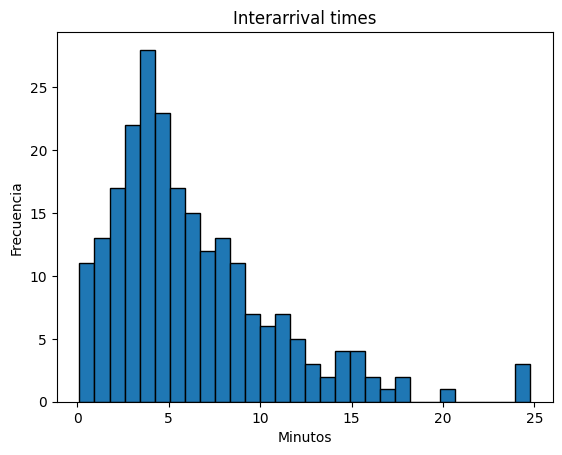

In [184]:
# Visualización exporatoria de variables

plt.hist(x_inter, bins=30, edgecolor="black")
plt.title("Interarrival times")
plt.xlabel("Minutos")
plt.ylabel("Frecuencia")
plt.show()


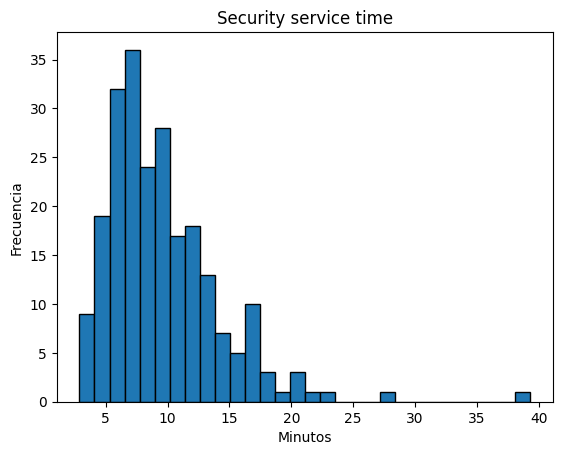

In [185]:
# Visualización exporatoria de variables

plt.hist(x_sec, bins=30, edgecolor="black")
plt.title("Security service time")
plt.xlabel("Minutos")
plt.ylabel("Frecuencia")
plt.show()


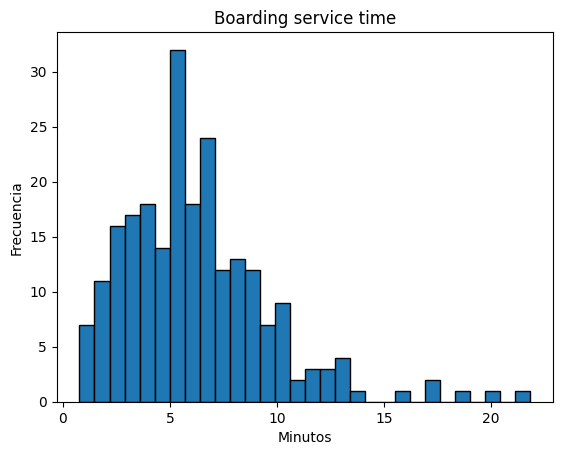

In [186]:
# Visualización exporatoria de variables

plt.hist(x_board, bins=30, edgecolor="black")
plt.title("Boarding service time")
plt.xlabel("Minutos")
plt.ylabel("Frecuencia")
plt.show()


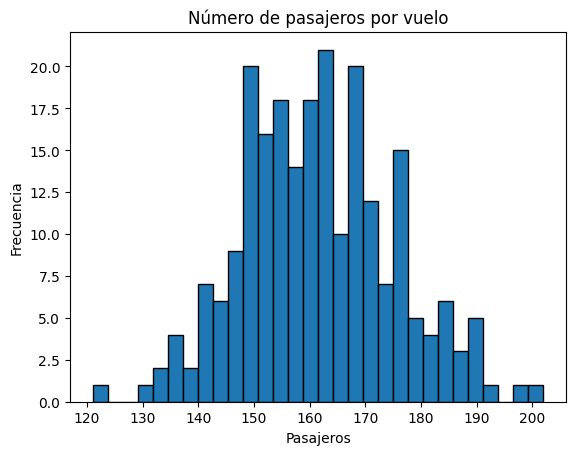

In [187]:
# Análisis exploratorio de variables

plt.hist(x_pass, bins=30, edgecolor="black")
plt.title("Número de pasajeros por vuelo")
plt.xlabel("Pasajeros")
plt.ylabel("Frecuencia")
plt.show()

## Estimación de Parámetros por MLE

Para cada variable y distribución candidata, se estiman los parámetros utilizando el método de máxima verosimilitud (MLE). Este método selecciona los parámetros que maximizan la probabilidad de observar los datos empíricos bajo el modelo propuesto. La estimación se realiza con la librería `scipy.stats`, que implementa MLE para una amplia variedad de distribuciones.

A partir de la naturaleza de cada variable, se proponen las siguientes distribuciones a probar. La selección se basa tanto en la forma empírica de los datos como en la interpretación estocástica del proceso. Una vez estimados los parámetros, se evalúa la calidad del ajuste utilizando pruebas estadísticas.

In [188]:
# Interarrival times ~ Gamma
params_inter = stats.gamma.fit(x_inter)

# Security service time ~ Lognormal
params_sec = stats.lognorm.fit(x_sec)

# Boarding service time ~ Weibull
params_board = stats.weibull_min.fit(x_board)

# Precio boleto ~ Normal
mu_, sigma_ = stats.norm.fit(x_price)

params_inter, params_sec, params_board, (mu_, sigma_)


((np.float64(1.9648027164083692),
  np.float64(-0.06234058658913326),
  np.float64(3.230892598259481)),
 (np.float64(0.47541323171620065),
  0.575662103212248,
  np.float64(8.025764845212196)),
 (np.float64(1.4073377159768687),
  np.float64(1.8988167238513762),
  np.float64(4.947473165100857)),
 (np.float64(118829.02620087336), np.float64(223366.65794687756)))

## Pruebas Bondad de ajuste


#### Kolmogórov–Smirnov (KS)

La prueba KS compara la función de distribución empírica con la función de distribución teórica ajustada. En muestras grandes, esta prueba tiende a rechazar con facilidad, por lo que se utiliza principalmente para comparar modelos relativos más que como un veredicto absoluto.

#### Anderson–Darling (AD)

La prueba Anderson–Darling es más sensible a las colas de la distribución, lo cual es especialmente relevante en sistemas de colas donde los valores extremos tienen gran impacto operativo. Para distribuciones lognormales, se aplica la prueba sobre el logaritmo de los datos, contrastando normalidad.

#### Chi-cuadrado (χ²)

La prueba Chi-cuadrado evalúa la bondad de ajuste comparando las frecuencias observadas en intervalos (bins) con las frecuencias esperadas según la distribución teórica ajustada. Es especialmente útil para variables discretas (como el conteo de pasajeros) y para validar el ajuste en distribuciones continuas cuando se agrupan los datos en clases.

### Kolmogorov-Smirnov Test

In [189]:
# Se realiza la prueba de Kolmogorov-Smirnov
ks_inter = stats.kstest(x_inter, "gamma", args=params_inter)
ks_sec   = stats.kstest(x_sec, "lognorm", args=params_sec)
ks_board = stats.kstest(x_board, "weibull_min", args=params_board)
ks_precio = stats.kstest(x_price, "norm", args=((mu_, sigma_)))
ks_inter, ks_sec, ks_board, ks_precio


(KstestResult(statistic=np.float64(0.04748343550732473), pvalue=np.float64(0.6621790618776224), statistic_location=np.float64(2.908088111955363), statistic_sign=np.int8(-1)),
 KstestResult(statistic=np.float64(0.03071937419011539), pvalue=np.float64(0.9775991867785565), statistic_location=np.float64(9.277413688409903), statistic_sign=np.int8(1)),
 KstestResult(statistic=np.float64(0.06961923415298171), pvalue=np.float64(0.2071134669326905), statistic_location=np.float64(2.444323856535864), statistic_sign=np.int8(1)),
 KstestResult(statistic=np.float64(0.04096167117647609), pvalue=np.float64(0.8215850991964446), statistic_location=np.int64(48954), statistic_sign=np.int8(-1)))

In [190]:
# Se muestran los P-values obtenidos
print("Interarrival times p-value:", ks_inter.pvalue)
print("Security service time p-value:", ks_sec.pvalue)
print("Boarding service time p-value:", ks_board.pvalue)
print("Precio boleto p-value:", ks_precio.pvalue)

Interarrival times p-value: 0.6621790618776224
Security service time p-value: 0.9775991867785565
Boarding service time p-value: 0.2071134669326905
Precio boleto p-value: 0.8215850991964446


In [191]:
# Mostrar resultados e interpretación para interarrival times
alpha = 0.05
print("Interarrival times ~ Gamma")
print(f"Parameters: {params_inter}")
print(f"K-S test: {ks_inter}\n")
if ks_inter.pvalue < alpha:
    print("Interarrival times: p < 0.05 → Se RECHAZA la hipótesis de ajuste Gamma.")
    print("Interpretación: los datos no se ajustan bien a una Gamma.\n")
else:
    print("Interarrival times: p >= 0.05 → No se rechaza la hipótesis de ajuste Gamma.")
    print("Interpretación: los datos se ajustan bien a una Gamma.\n")

Interarrival times ~ Gamma
Parameters: (np.float64(1.9648027164083692), np.float64(-0.06234058658913326), np.float64(3.230892598259481))
K-S test: KstestResult(statistic=np.float64(0.04748343550732473), pvalue=np.float64(0.6621790618776224), statistic_location=np.float64(2.908088111955363), statistic_sign=np.int8(-1))

Interarrival times: p >= 0.05 → No se rechaza la hipótesis de ajuste Gamma.
Interpretación: los datos se ajustan bien a una Gamma.



In [192]:
# Mostrar resultados e interpretación para security service time
print("Security service time ~ Lognormal")
print(f"Parameters: {params_sec}")
print(f"K-S test: {ks_sec}\n")
if ks_sec.pvalue < alpha:
    print("Security service time: p < 0.05 → Se RECHAZA la hipótesis de ajuste Lognormal.")
    print("Interpretación: los datos no se ajustan bien a una Lognormal.\n")
else:
    print("Security service time: p >= 0.05 → No se rechaza la hipótesis de ajuste Lognormal.")
    print("Interpretación: los datos se ajustan bien a una Lognormal.\n")

Security service time ~ Lognormal
Parameters: (np.float64(0.47541323171620065), 0.575662103212248, np.float64(8.025764845212196))
K-S test: KstestResult(statistic=np.float64(0.03071937419011539), pvalue=np.float64(0.9775991867785565), statistic_location=np.float64(9.277413688409903), statistic_sign=np.int8(1))

Security service time: p >= 0.05 → No se rechaza la hipótesis de ajuste Lognormal.
Interpretación: los datos se ajustan bien a una Lognormal.



In [193]:
# Mostrar resultados e interpretación para boarding service time
print("Boarding service time ~ Weibull")
print(f"Parameters: {params_board}")
print(f"K-S test: {ks_board}\n") 
if ks_board.pvalue < alpha:
    print("Boarding service time: p < 0.05 → Se RECHAZA la hipótesis de ajuste Weibull.")
    print("Interpretación: los datos no se ajustan bien a una Weibull.\n")
else:
    print("Boarding service time: p >= 0.05 → No se rechaza la hipótesis de ajuste Weibull.")
    print("Interpretación: los datos se ajustan bien a una Weibull.\n")

Boarding service time ~ Weibull
Parameters: (np.float64(1.4073377159768687), np.float64(1.8988167238513762), np.float64(4.947473165100857))
K-S test: KstestResult(statistic=np.float64(0.06961923415298171), pvalue=np.float64(0.2071134669326905), statistic_location=np.float64(2.444323856535864), statistic_sign=np.int8(1))

Boarding service time: p >= 0.05 → No se rechaza la hipótesis de ajuste Weibull.
Interpretación: los datos se ajustan bien a una Weibull.



In [194]:
# Mostrar resultados e interpretación para precio boleto
print("Precio boleto ~ Normal")
print(f"Parameters: mu={mu_}, sigma={sigma_}")
print(f"K-S test: {ks_precio}\n")
if ks_precio.pvalue < alpha:
    print("Precio boleto: p < 0.05 → Se RECHAZA la hipótesis de ajuste Normal.")
    print("Interpretación: los datos no se ajustan bien a una Normal.\n")
else:
    print("Precio boleto: p >= 0.05 → No se rechaza la hipótesis de ajuste Normal.")
    print("Interpretación: los datos se ajustan bien a una Normal.\n")

Precio boleto ~ Normal
Parameters: mu=118829.02620087336, sigma=223366.65794687756
K-S test: KstestResult(statistic=np.float64(0.04096167117647609), pvalue=np.float64(0.8215850991964446), statistic_location=np.int64(48954), statistic_sign=np.int8(-1))

Precio boleto: p >= 0.05 → No se rechaza la hipótesis de ajuste Normal.
Interpretación: los datos se ajustan bien a una Normal.



### Anderson- Darling Test

In [195]:
# Seleccionar la variable para la prueba de Anderson-Darling
x_exp = x_wait  

# Anderson–Darling para Exponencial
ad_exp = stats.anderson(x_exp, dist="expon")

print("AD (Exponencial) statistic:", ad_exp.statistic)
print("AD critical values:", ad_exp.critical_values)
print("AD significance levels:", ad_exp.significance_level)

# Decisión al 5% (índice 2 corresponde a 5%)
if ad_exp.statistic < ad_exp.critical_values[2]:
    print("p >= 0.05 → No se rechaza la hipótesis de ajuste Exponencial.")
    print("Interpretación: los datos se ajustan bien a una Exponencial.\n")
else:
    print("p < 0.05 → Se RECHAZA la hipótesis de ajuste Exponencial.")
    print("Interpretación: los datos no se ajustan bien a una Exponencial.\n")

AD (Exponencial) statistic: 0.582218747978203
AD critical values: [0.92  1.075 1.337 1.602 1.952]
AD significance levels: [15.  10.   5.   2.5  1. ]
p >= 0.05 → No se rechaza la hipótesis de ajuste Exponencial.
Interpretación: los datos se ajustan bien a una Exponencial.



In [196]:
# Seleccionar la variable para la prueba de Anderson-Darling
x_logn = x_sec  

# Importante: log requiere datos estrictamente positivos
x_logn_pos = x_logn[x_logn > 0]

# Transformación log
z = np.log(x_logn_pos)

# Anderson–Darling para Normalidad del log
ad_logn = stats.anderson(z, dist="norm")

print("AD (Normalidad de log(X)) statistic:", ad_logn.statistic)
print("AD critical values:", ad_logn.critical_values)
print("AD significance levels:", ad_logn.significance_level)

# Decisión al 5%
if ad_logn.statistic < ad_logn.critical_values[2]:
    print("p >= 0.05 → No se rechaza la hipótesis de ajuste Lognormal.")
    print("Interpretación: los datos se ajustan bien a una Lognormal.\n")
else:
    print("p < 0.05 → Se RECHAZA la hipótesis de ajuste Lognormal.")
    print("Interpretación: los datos no se ajustan bien a una Lognormal.\n")

AD (Normalidad de log(X)) statistic: 0.1981788894219676
AD critical values: [0.566 0.645 0.774 0.903 1.074]
AD significance levels: [15.  10.   5.   2.5  1. ]
p >= 0.05 → No se rechaza la hipótesis de ajuste Lognormal.
Interpretación: los datos se ajustan bien a una Lognormal.



## Sistema de Colas


Una vez ajustadas las distribuciones empíricas, se pueden utilizar los parámetros estimados para alimentar modelos clásicos de teoría de colas. En este caso, se analiza el sistema de embarque del aeropuerto, que cuenta con **2 counters** (servidores) y se modela bajo dos enfoques complementarios.


#### Modelo M/M/2 (Exponencial en servicio)

El primer enfoque asume que tanto los tiempos entre llegadas como los tiempos de servicio siguen distribuciones exponenciales. Este es el modelo **M/M/s** clásico, donde:

- **M**: llegadas según un proceso de Poisson (tiempos entre llegadas exponenciales)
- **M**: tiempos de servicio exponenciales
- **2**: número de servidores (counters)

#### Parámetros del sistema

- **λ (lambda)**: tasa de llegadas (llegadas por minuto) = 1 / E[interarrival]
- **μ (mu)**: tasa de servicio por servidor (servicios por minuto) = 1 / E[service_time]
- **s**: número de servidores = 2
- **ρ_s**: utilización del sistema = λ / (s × μ)

#### Condición de estabilidad

Para que el sistema tenga un estado estacionario, se requiere que **ρ_s < 1**. Si ρ_s ≥ 1, el sistema es inestable y las colas crecen indefinidamente.

#### Métricas de desempeño (vía CTMC)

El modelo se resuelve mediante Cadenas de Markov de Tiempo Continuo (CTMC), utilizando las fórmulas de Kendall:

1. **π₀**: probabilidad de que el sistema esté vacío
2. **P(X ≥ s)**: probabilidad de que todas las estaciones estén ocupadas (probabilidad de espera)
3. **L_q**: número esperado de clientes en cola
4. **L_s**: número esperado de clientes en servicio = λ / μ
5. **L**: número esperado de clientes en el sistema = L_q + L_s
6. **W_q**: tiempo esperado en cola (usando Ley de Little: W_q = L_q / λ)
7. **W**: tiempo esperado en el sistema = W_q + E[S]



#### Modelo M/G/2 (Servicio general - Weibull)

En la práctica, los tiempos de servicio **no siempre son exponenciales**. El análisis exploratorio y las pruebas de bondad de ajuste pueden indicar que otra distribución (como Weibull o Lognormal) se ajusta mejor a los datos.

El modelo **M/G/s** extiende el M/M/s permitiendo una distribución general para el tiempo de servicio, caracterizada por:

- **E[S]**: media del tiempo de servicio
- **E[S²]**: segundo momento del tiempo de servicio
- **C_s²**: coeficiente de variación al cuadrado = (Var(S)) / (E[S])²

#### Ajuste Weibull para tiempos de servicio

Se utiliza **máxima verosimilitud (MLE)** para estimar los parámetros de la distribución Weibull:

- **c**: parámetro de forma (shape)
- **scale**: parámetro de escala
- **loc**: parámetro de ubicación (usualmente fijado en 0 para tiempos positivos)

A partir de estos parámetros, se calculan:
- E[S]: media teórica de la Weibull ajustada
- E[S²]: segundo momento teórico
- C_s²: coeficiente de variación

#### Aproximación M/G/2

Para sistemas M/G/s **no existe una solución exacta en forma cerrada** (excepto para s=1). Se utilizan **aproximaciones**, como la corrección por variabilidad:

**W_q (M/G/2) ≈ [(C_a² + C_s²) / 2] × W_q (M/M/2)**

Donde:
- **C_a²**: coeficiente de variación de los tiempos entre llegadas (= 1 para proceso Poisson)
- **C_s²**: coeficiente de variación de los tiempos de servicio (calculado de la Weibull)
- **W_q (M/M/2)**: tiempo en cola del modelo exponencial equivalente

Esta aproximación ajusta el tiempo de espera considerando la **variabilidad adicional** introducida por la distribución de servicio no-exponencial.


#### Comparación de modelos

| Métrica | M/M/2 (Exponencial) | M/G/2 (Weibull) |
|---------|---------------------|-----------------|
| Supuesto | Servicio exponencial | Servicio general (Weibull) |
| Solución | Exacta (CTMC) | Aproximación |
| Variabilidad | C_s² = 1 (siempre) | C_s² estimado de datos |
| Aplicabilidad | Buena para análisis inicial | Más realista para datos reales |

#### Interpretación práctica

- Si **C_s² ≈ 1**: ambos modelos coinciden
- Si **C_s² > 1**: el servicio tiene mayor variabilidad → W_q (M/G/2) > W_q (M/M/2)
- Si **C_s² < 1**: el servicio es más regular → W_q (M/G/2) < W_q (M/M/2)

El modelo M/G/2 captura mejor la variabilidad real del sistema y proporciona estimaciones más precisas del desempeño operativo del aeropuerto.



In [198]:
# Modelar sistema de colas M/M/2 para embarque
# Modelado como una cola M/M/s vía CTMC (Kendall)

lam = 1 / np.mean(x_inter)   # llegadas por minuto
ES  = np.mean(x_board)       # E[S] en minutos
mu  = 1 / ES                 # servicios por minuto (por servidor)

s = 2                        # 2 counters

rho_s = lam / (s * mu)

print("lambda (lleg/min):", lam)
print("mu (serv/min por servidor):", mu)
print("rho_s:", rho_s)

if rho_s >= 1:
    print("Sistema inestable (rho_s >= 1). No existe estado estable.")
else:
    # ----------------------------
    # pi_0
    # ----------------------------
    a = s * rho_s   # a = λ/μ  (equivale a s*rho_s)

    sum_1 = sum((a**j)/factorial(j) for j in range(s))
    sum_2 = (a**s) / (factorial(s) * (1 - rho_s))
    pi0 = 1 / (sum_1 + sum_2)

    # ----------------------------
    # Lq
    # ----------------------------
    P_wait = (a**s) / (factorial(s) * (1 - rho_s)) * pi0   # P(X>=s)
    Lq = P_wait * (rho_s / (1 - rho_s))

    # ----------------------------
    # Ls y L
    # ----------------------------
    Ls = lam / mu
    L = Lq + Ls

    # ----------------------------
    # Wq y W (Little)
    # ----------------------------
    Wq = Lq / lam
    W  = L / lam

    print("\n--- Resultados M/M/2 (vía Kendall / CTMC) ---")
    print("pi0 =", pi0)
    print("P(X>=s) =", P_wait)
    print("Lq =", Lq, "personas")
    print("Ls =", Ls, "personas")
    print("L  =", L, "personas")
    print("Wq (min) =", Wq, "min")
    print("W  (min) =", W, "min")
    print("Wq (min) =", Wq, "min")
    print("W  (min) =", W, "min")
    Wq_mm2 = Wq
    W_mm2  = W

lambda (lleg/min): 0.15909171121367555
mu (serv/min por servidor): 0.1596819951727681
rho_s: 0.4981516890540668

--- Resultados M/M/2 (vía Kendall / CTMC) ---
pi0 = 0.3349783033404316
P(X>=s) = 0.33128168144856524
Lq = 0.3288414558080549 personas
Ls = 0.9963033781081336 personas
L  = 1.3251448339161884 personas
Wq (min) = 2.066993014905654 min
W  (min) = 8.329439816863815 min
Wq (min) = 2.066993014905654 min
W  (min) = 8.329439816863815 min


In [199]:
# Modelar sistema de colas M/M/2 para embarque
# Modelo analítico vía Weibull

# Ajuste Weibull (weibull_min) por MLE
# params = (c, loc, scale)
c, loc, scale = stats.weibull_min.fit(x_board, floc=0)  # floc=0 (tiempos positivos)

# Momentos teóricos de la Weibull ajustada
ES  = stats.weibull_min.mean(c, loc=0, scale=scale)       # E[S]
ES2 = stats.weibull_min.moment(2, c, loc=0, scale=scale)  # E[S^2]

VarS = ES2 - ES**2
Cs2 = VarS / (ES**2)

print("Weibull fit (boarding):")
print("shape c =", c)
print("scale =", scale)
print("E[S]  =", ES)
print("E[S^2]=", ES2)
print("Var[S] =", VarS)
print("Cs^2  =", Cs2)


Weibull fit (boarding):
shape c = 1.9267951192491304
scale = 7.0816719681422775
E[S]  = 6.2813737723554
E[S^2]= 50.98567788029515
Var[S] = 11.530021412260837
Cs^2  = 0.29222733682310126


In [200]:
# Llegadas y parámetros para 2 counters
Ca2 = 1.0
x_inter = df["interarrival_min"].values
x_inter = x_inter[np.isfinite(x_inter)]
x_inter = x_inter[x_inter > 0]

lam = 1 / np.mean(x_inter)   # llegadas por minuto

s = 2                        # 2 counters
mu = 1 / ES                  # tasa de servicio por servidor (serv/min)

rho_s = lam / (s * mu)

print("lambda (lleg/min) =", lam)
print("mu (serv/min por servidor) =", mu)
print("rho_s =", rho_s)

lambda (lleg/min) = 0.15909171121367555
mu (serv/min por servidor) = 0.15920084303867468
rho_s = 0.49965725110836057


In [201]:
if rho_s < 1:

    Wq_mg2 = ((Ca2 + Cs2) / 2) * Wq_mm2
    W_mg2  = Wq_mg2 + ES

    print("\n--- Aproximación M/G/2 usando Weibull en servicio ---")
    print("Factor variabilidad =", (Ca2 + Cs2)/2)
    print("Wq (M/G/2 aprox) =", Wq_mg2, "min")
    print("W  (M/G/2 aprox) =", W_mg2, "min")



--- Aproximación M/G/2 usando Weibull en servicio ---
Factor variabilidad = 0.6461136684115506
Wq (M/G/2 aprox) = 1.335512439441743 min
W  (M/G/2 aprox) = 7.616886211797143 min


Usando la aproximación de corrección por variabilidad,

$$
W_q^{M/G/2} \approx \frac{1 + C_s^2}{2}\, W_q^{M/M/2}
$$

Como:

$$
C_s^2 = 0.292
$$

El factor de corrección es:

$$
\frac{1 + 0.292}{2} = 0.646
$$

Por tanto, el tiempo esperado en cola disminuye de:

$$
W_q^{M/M/2} = 2.067 \text{ min}
$$

a

$$
W_q^{M/G/2} = 0.646 \times 2.067 = 1.336 \text{ min}
$$

El tiempo total esperado en el sistema es:

$$
W^{M/G/2} = W_q^{M/G/2} + E[S]
$$

$$
W^{M/G/2} = 1.336 + 6.281 = 7.617 \text{ min}
$$

Dado que:

$$
C_s^2 = 0.292 < 1,
$$

el servicio es más regular que el supuesto exponencial (donde $C_s^2 = 1$), lo que explica la reducción en el tiempo de espera respecto al modelo M/M/2.
